In [ ]:
# !pip install pyspark

In [1]:
# prompt: inicia meu google nuvem

# from google.colab import drive
# drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Iniciando uma sessão
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master('local[*]') \
    .appName("monitoramento_1.0") \
    .getOrCreate()

In [ ]:
import pandas as pd

df = pd.read_excel('noticias_tcc_2025.xlsx')
df = pd.read_excel('noticias_tcc_2025.xlsx', engine='openpyxl').fillna("Nihil")
df = df.replace(r'\n', ' ', regex=True)
colunas = df.columns.tolist()

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1517 entries, 0 to 1516
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             1517 non-null   int64 
 1   titulo         1517 non-null   object
 2   noticia        1517 non-null   object
 3   dt             1517 non-null   object
 4   classificacao  1517 non-null   object
dtypes: int64(1), object(4)
memory usage: 59.4+ KB


In [ ]:
for col in colunas:
  if col == "noticia"  or col =='summary':
    df[col] = df[col].str.replace(r'\\r|\\n|\\r\\n|_x000D_', '', regex=True)


In [ ]:
csv = bytes(df.to_csv(index=False), encoding='utf-8')
with open('noticias_tcc_2025.csv', 'wb') as f:
    f.write(csv)


In [ ]:
df = spark.read.csv("noticias_tcc_2025.csv",header=True, sep=',')

In [ ]:

# Ler o arquivo CSV com opções adicionais para tratamento de aspas
df = spark.read.option("delimiter", ",").option("quote", "\"").option("escape", "\"").csv("noticias_tcc_2025.csv", header=True, inferSchema=True)

df.show(300,truncate=False)


+---------+---------------------------------------------------------------------------------------------------------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
colunas = df.columns
colunas

['id', 'titulo', 'noticia', 'dt', 'classificacao']

In [ ]:
df.select('noticia','classificacao').show(2,truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
# from transformers import pipeline

# classifier = pipeline("zero-shot-classification",
#                       model="joeddav/xlm-roberta-large-xnli")

# labels = ["Economia", "Risco Político", "Risco Regulatório",
#           "Risco Cibernético", "Risco Ambiental", "Sem Relação"]

# noticia = " A taxa de juros Selic acabou de aumentar para 15%."
# result = classifier(noticia, candidate_labels=labels, hypothesis_template="Esta notícia é sobre {}.")
# print(result)

In [ ]:
from pyspark.sql import functions as F
colunas = df.columns
for col in colunas:
    df = df.withColumn(col, F.trim(F.col(col)))

df.show()


+---------+--------------------+--------------------+--------------------+-------------+
|       id|              titulo|             noticia|                  dt|classificacao|
+---------+--------------------+--------------------+--------------------+-------------+
|109007380|Mercado financeir...|A previsão do mer...|2025-08-25T09:48:00Z|           C1|
|109041211|'A tarifação não ...|Merenda e estoque...|2025-08-25T21:18:00Z|           C1|
|109039898|AGU pede investig...|A Advocacia Geral...|2025-08-25T21:00:00Z|           C7|
|109000334|  Cartas de Leitores|Política na educa...|2025-08-25T00:00:00Z|           C7|
|109048853|AGU pede a Políci...|A Advocacia Geral...|2025-08-25T20:58:58Z|           C7|
|108999933|Abertura do merca...|247 - A abertura ...|2025-08-25T00:00:00Z|           C1|
|109000262|Comércio on-line ...|O faturamento com...|2025-08-25T00:00:00Z|           C1|
|109000278|Incentivos tribut...|COLUNISTAS - Brun...|2025-08-25T00:00:00Z|           C1|
|109000282|Sob pressã

In [ ]:
df.groupBy('classificacao').count().show(truncate=False)

+-------------+-----+
|classificacao|count|
+-------------+-----+
|C6           |122  |
|C3           |54   |
|C4           |66   |
|C5           |73   |
|C1           |309  |
|C2           |150  |
|C7           |743  |
+-------------+-----+



In [ ]:

# from pyspark.sql.functions import col

# df_filtrado = df.filter(~col("classificacao").startswith("c4"))
# df_filtrado.groupBy('classificacao').count().show(truncate=False)
# df = df_filtrado


In [ ]:
df = df.select('id','noticia','classificacao')
df.show()

+---------+--------------------+-------------+
|       id|             noticia|classificacao|
+---------+--------------------+-------------+
|109007380|A previsão do mer...|           C1|
|109041211|Merenda e estoque...|           C1|
|109039898|A Advocacia Geral...|           C7|
|109000334|Política na educa...|           C7|
|109048853|A Advocacia Geral...|           C7|
|108999933|247 - A abertura ...|           C1|
|109000262|O faturamento com...|           C1|
|109000278|COLUNISTAS - Brun...|           C1|
|109000282|Empresas de papel...|           C1|
|109000298|A temporada de ba...|           C1|
|109000299|A combinação de e...|           C1|
|109000300|Mais de dois terç...|           C1|
|109000301|Desde julho, volt...|           C1|
|109000327|O Brasil tem hoje...|           C1|
|109000366|As famílias brasi...|           C1|
|109000389|Por determinação ...|           C1|
|109000753|A Receita Federal...|           C1|
|109001805|247 - O projeto d...|           C1|
|109003349|24

# Limpeza

In [ ]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

## Testando a remoção dos caracteres especiais

In [ ]:
import pyspark.sql.functions as f
df_2 = df.withColumn("txt_sem_especiais", f.regexp_replace("noticia","[\"!%&'()*+-./:;<=>?@^_`´{|}~\\\\]", ""))
df_2 = df_2.withColumn("texto_limpo",f.trim(df_2.txt_sem_especiais))
df_2.show(truncate=True)

+---------+--------------------+-------------+--------------------+--------------------+
|       id|             noticia|classificacao|   txt_sem_especiais|         texto_limpo|
+---------+--------------------+-------------+--------------------+--------------------+
|109007380|A previsão do mer...|           C1|A previsão do mer...|A previsão do mer...|
|109041211|Merenda e estoque...|           C1|Merenda e estoque...|Merenda e estoque...|
|109039898|A Advocacia Geral...|           C7|A Advocacia Geral...|A Advocacia Geral...|
|109000334|Política na educa...|           C7|Política na educa...|Política na educa...|
|109048853|A Advocacia Geral...|           C7|A Advocacia Geral...|A Advocacia Geral...|
|108999933|247 - A abertura ...|           C1|247  A abertura d...|247  A abertura d...|
|109000262|O faturamento com...|           C1|O faturamento com...|O faturamento com...|
|109000278|COLUNISTAS - Brun...|           C1|COLUNISTAS  Bruno...|COLUNISTAS  Bruno...|
|109000282|Empresas d

In [ ]:
from pyspark.sql.types import IntegerType
countTokens = f.udf(lambda tokens: len(tokens),IntegerType())

## Pipeline : Executar tudo de uma vez

In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer, IDF, StringIndexer
from pyspark.ml.classification import DecisionTreeClassifier, RandomForestClassifier, NaiveBayes
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.sql.functions import udf
from pyspark.sql.types import IntegerType
countTokens = f.udf(lambda tokens: len(tokens),IntegerType())


stop = StopWordsRemover.loadDefaultStopWords("portuguese")
tokenizer = Tokenizer(inputCol="texto_limpo",outputCol ="tokens")
stopwords = StopWordsRemover(inputCol="tokens", outputCol="texto_final",stopWords=stop)
cv = CountVectorizer(inputCol="texto_final",outputCol="CountVec")
#hashingTF = HashingTF(inputCol=stopwords.getOutputCol(), outputCol="HTF", numFeatures=1000)
tfidf = IDF(inputCol="CountVec",outputCol="features")

pipeline = Pipeline(stages = [tokenizer,stopwords, cv, tfidf])

In [ ]:
dados_transformados = pipeline.fit(df_2).transform(df_2)

In [ ]:
# Contagem de tokens antes e depois do stopwords.
dados_transformados.select("tokens", "texto_final")\
          .withColumn("Freq_tokens", countTokens(f.col("tokens")))\
          .withColumn("Freq_tokens_limpos",  countTokens(f.col("texto_final"))).show()

+--------------------+--------------------+-----------+------------------+
|              tokens|         texto_final|Freq_tokens|Freq_tokens_limpos|
+--------------------+--------------------+-----------+------------------+
|[a, previsão, do,...|[previsão, mercad...|        596|               364|
|[merenda, e, esto...|[merenda, estoque...|        937|               667|
|[a, advocacia, ge...|[advocacia, geral...|         80|                49|
|[política, na, ed...|[política, educaç...|        607|               412|
|[a, advocacia, ge...|[advocacia, geral...|         99|                66|
|[247, , a, abertu...|[247, , abertura,...|        491|               331|
|[o, faturamento, ...|[faturamento, ven...|        816|               569|
|[colunistas, , br...|[colunistas, , br...|       1071|               741|
|[empresas, de, pa...|[empresas, papel,...|       1114|               778|
|[a, temporada, de...|[temporada, balan...|        436|               284|
|[a, combinação, d...|[co

In [ ]:
dados_transformados.show()

+---------+--------------------+-------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|       id|             noticia|classificacao|   txt_sem_especiais|         texto_limpo|              tokens|         texto_final|            CountVec|            features|
+---------+--------------------+-------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|109007380|A previsão do mer...|           C1|A previsão do mer...|A previsão do mer...|[a, previsão, do,...|[previsão, mercad...|(38420,[0,2,4,5,6...|(38420,[0,2,4,5,6...|
|109041211|Merenda e estoque...|           C1|Merenda e estoque...|Merenda e estoque...|[merenda, e, esto...|[merenda, estoque...|(38420,[0,2,3,5,6...|(38420,[0,2,3,5,6...|
|109039898|A Advocacia Geral...|           C7|A Advocacia Geral...|A Advocacia Geral...|[a, advocacia, ge...|[advocacia, geral...|(3842


## Nuvem de palavras (wordcloud)

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

amostra = dados_transformados.select('texto_final').sample(fraction=0.4,seed=101)
tudo = [noticia['texto_final'] for noticia in amostra.collect()]


In [ ]:
wordcloud = WordCloud(background_color='white',
                      width = 1000,
                      height = 600,
                      collocations = False,
                      prefer_horizontal = 1).generate(str(tudo))


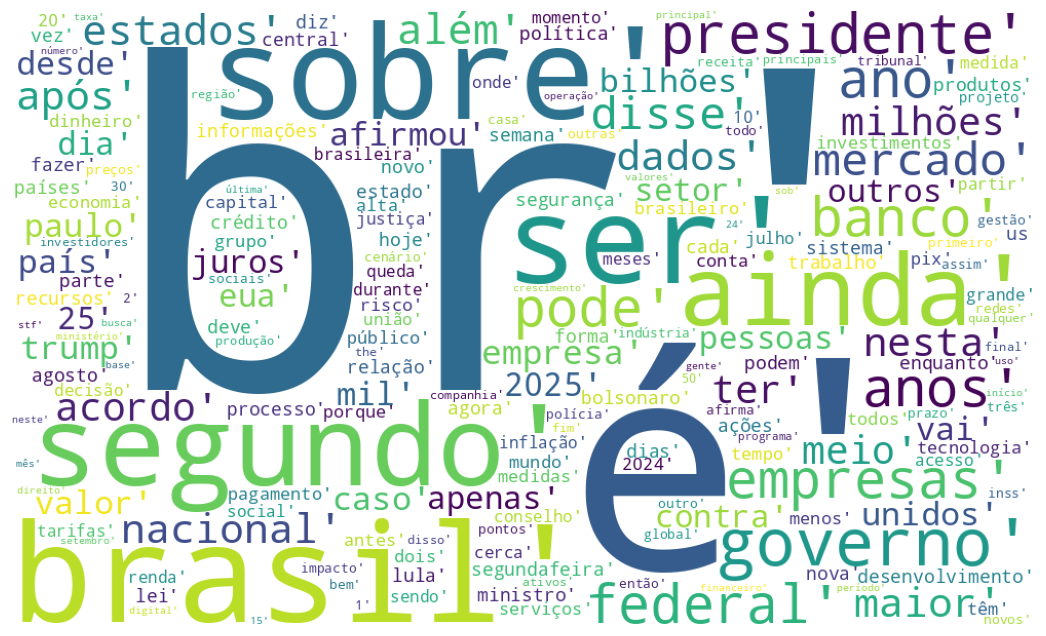

In [ ]:
plt.figure(figsize=(20,8))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()


#### **Codificando**: variável resposta.


In [ ]:
# Codificando a variável resposta.
# 1. replace
# 2. stringindexer (sentiment -> label)

from pyspark.ml.feature import StringIndexer

stringindexer = StringIndexer(inputCol="classificacao", outputCol="label")
dados = stringindexer.fit(df_2).transform(df_2)

In [ ]:
dados.groupBy(['classificacao','label']).count().show(truncate=False)

+-------------+-----+-----+
|classificacao|label|count|
+-------------+-----+-----+
|C1           |1.0  |309  |
|C5           |4.0  |73   |
|C7           |0.0  |743  |
|C3           |6.0  |54   |
|C2           |2.0  |150  |
|C4           |5.0  |66   |
|C6           |3.0  |122  |
+-------------+-----+-----+



# Modelos

## Aplicação dos 3 modelos separadamente atráves de Pipeline

In [ ]:
dados.show(1)

+---------+--------------------+-------------+--------------------+--------------------+-----+
|       id|             noticia|classificacao|   txt_sem_especiais|         texto_limpo|label|
+---------+--------------------+-------------+--------------------+--------------------+-----+
|109007380|A previsão do mer...|           C1|A previsão do mer...|A previsão do mer...|  1.0|
+---------+--------------------+-------------+--------------------+--------------------+-----+
only showing top 1 row


In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer, IDF, StringIndexer
from pyspark.ml.classification import DecisionTreeClassifier, RandomForestClassifier, NaiveBayes
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

dados = df
dados = dados.filter(dados['noticia'] !="Nihil")
dados = dados.withColumn("texto_transformado", f.regexp_replace("NOTICIA","[\"!%&'()*+-./:;<=>?@^_`´{|}~\\\\]", ""))
dados = dados.withColumn("texto_limpo",f.trim(dados.texto_transformado))


# Definição das etapas do pipeline
labelIndexer = StringIndexer(inputCol="classificacao", outputCol="label").fit(dados)
tokenizer =  Tokenizer(inputCol="texto_limpo", outputCol="tokens")
stopwords = StopWordsRemover(inputCol="tokens", outputCol="texto_final")
cv = CountVectorizer(inputCol="texto_final", outputCol="CountVec")
tfidf = IDF(inputCol="CountVec", outputCol="features")


# Classificadores
dt = DecisionTreeClassifier(featuresCol='features', labelCol='label', maxDepth=5)
rf = RandomForestClassifier(featuresCol='features', labelCol='label')
nb = NaiveBayes(featuresCol='features', labelCol='label')


# Dividir os dados em conjuntos de treinamento e teste
treino_dados, teste_dados = dados.randomSplit([0.7, 0.3], seed=42)

# Pipeline de pré-processamento para utilizar no KNN
pipeline = Pipeline(stages=[labelIndexer, tokenizer, stopwords, cv, tfidf])
# Criação do pipeline com os classificadores
pipeline_dt = Pipeline(stages=[labelIndexer, tokenizer, stopwords, cv, tfidf, dt])
pipeline_rf = Pipeline(stages=[labelIndexer, tokenizer, stopwords, cv, tfidf, rf])
pipeline_nb = Pipeline(stages=[labelIndexer, tokenizer, stopwords, cv, tfidf, nb])

## Arvore de decisão

In [ ]:

# Ajuste e transformação dos dados para cada pipeline
treino_dt = pipeline_dt.fit(treino_dados)
previsoes_dt = treino_dt.transform(teste_dados)

# Avaliação dos modelos
evaluator_acuracia = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
# evaluator_precision = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="precisionByLabel")
# evaluator_recall = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="recallByLabel")
evaluator_precision = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
evaluator_recall = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")


acuracia_dt = evaluator_acuracia.evaluate(previsoes_dt)
f1_score = evaluator_f1.evaluate(previsoes_dt)
precision = evaluator_precision.evaluate(previsoes_dt)
recall = evaluator_recall.evaluate(previsoes_dt)

# Organizar as métricas em um DataFrame
metricas = pd.DataFrame({
    "Métrica": ["Acurácia","F1-Score", "Precisão", "Recall"],
    "Valor": [acuracia_dt,f1_score, precision, recall]
})
print(metricas)

    Métrica     Valor
0  Acurácia  0.659314
1  F1-Score  0.631057
2  Precisão  0.680066
3    Recall  0.659314


## Cross Validation - Validação Cruzada

## Cross Validation

In [ ]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer, IDF, VectorAssembler, StringIndexer
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
# Combinar as features em uma única coluna

# Verifique se a coluna "category" existe no DataFrame
print(df_2.columns)

# Tokenização e remoção de stopwords para NOTICIA
tokenizer_noticia = Tokenizer(inputCol="noticia", outputCol="tokens_noticia")
stopwords_noticia = StopWordsRemover(inputCol="tokens_noticia", outputCol="texto_final_noticia")
cv_noticia = CountVectorizer(inputCol="texto_final_noticia", outputCol="CountVec_noticia")
tfidf_noticia = IDF(inputCol="CountVec_noticia", outputCol="features_noticia")
# Combinar as features em uma única coluna
assembler = VectorAssembler(inputCols=["features_noticia"], outputCol="features")



# Indexação da coluna "category" para criar a coluna "label"
labelIndexer = StringIndexer(inputCol="classificacao", outputCol="label", handleInvalid="keep")

# Dividir os dados em conjuntos de treinamento e teste
treino_dados, teste_dados = df_2.randomSplit([0.7, 0.3], seed=42)


# Classificador
dt = DecisionTreeClassifier(featuresCol="features", labelCol="label", maxDepth=5)

# Pipeline final
pipeline = Pipeline(stages=[
    labelIndexer,
    tokenizer_noticia, stopwords_noticia, cv_noticia, tfidf_noticia,
    assembler, dt
])

# Criar uma grade de parâmetros para ajustar (exemplo com maxDepth)
paramGrid = ParamGridBuilder() \
    .addGrid(dt.maxDepth, [5,7,10,15]) \
    .build()

# Definir o avaliador
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")

# Configurar o CrossValidator
crossval = CrossValidator(estimator=pipeline,
                          estimatorParamMaps=paramGrid,
                          evaluator=evaluator,
                          numFolds=10)  # Número de folds

# Ajustar o modelo usando CrossValidator
cvModel = crossval.fit(treino_dados)

# Fazer previsões no conjunto de teste
previsoes = cvModel.transform(teste_dados)

# Avaliar a acurácia
acuracia = evaluator.evaluate(previsoes)
print(f"Acurácia: {acuracia}")

['id', 'noticia', 'classificacao', 'txt_sem_especiais', 'texto_limpo']


KeyboardInterrupt: 

In [ ]:
# Obter o melhor modelo do CrossValidator
bestModel = cvModel.bestModel

# Verificar o valor de maxDepth escolhido
bestMaxDepth = bestModel.stages[-1].getOrDefault("maxDepth")
print(f"O melhor valor de maxDepth escolhido foi: {bestMaxDepth}")

## Random Forest - Diversas arvores de decisão

In [ ]:
# Ajuste e transformação dos dados para o Random Forest
treino_rf = pipeline_rf.fit(treino_dados)
previsoes_rf = treino_rf.transform(teste_dados)

# Avaliação dos modelos
evaluator_acuracia = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
evaluator_precision = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
evaluator_recall = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")

# Calcular métricas
acuracia_rf = evaluator_acuracia.evaluate(previsoes_rf)
f1_rf = evaluator_f1.evaluate(previsoes_rf)
precision_rf = evaluator_precision.evaluate(previsoes_rf)
recall_rf = evaluator_recall.evaluate(previsoes_rf)

# Organizar em DataFrame
metricas_rf = pd.DataFrame({
    "Métrica": ["Acurácia","F1-Score", "Precisão", "Recall"],
    "Valor": [acuracia_rf, f1_rf, precision_rf, recall_rf]
})

print(metricas_rf)


    Métrica     Valor
0  Acurácia  0.573529
1  F1-Score  0.462937
2  Precisão  0.531942
3    Recall  0.573529


## Naive Bayes

In [ ]:
# Ajuste e transformação dos dados para o Naive Bayes
treino_nb = pipeline_nb.fit(treino_dados)
previsoes_nb = treino_nb.transform(teste_dados)

# Avaliação dos modelos
evaluator_acuracia = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
evaluator_precision = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
evaluator_recall = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")

# Calcular métricas
acuracia_nb = evaluator_acuracia.evaluate(previsoes_nb)
f1_nb = evaluator_f1.evaluate(previsoes_nb)
precision_nb = evaluator_precision.evaluate(previsoes_nb)
recall_nb = evaluator_recall.evaluate(previsoes_nb)

# Organizar em DataFrame
metricas_nb = pd.DataFrame({
    "Métrica": ["Acurácia","F1-Score", "Precisão", "Recall"],
    "Valor": [acuracia_nb, f1_nb, precision_nb, recall_nb]
})

print(metricas_nb)


    Métrica     Valor
0  Acurácia  0.806373
1  F1-Score  0.807813
2  Precisão  0.818233
3    Recall  0.806373


## Modelo KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


# Ajuste e transformação dos dados de treinamento e teste
modelo = pipeline.fit(treino_dados)

In [ ]:
treino_dados_transformed = modelo.transform(treino_dados)
teste_dados_transformed = modelo.transform(teste_dados)

treino_dados_transformed.show()

+---------+--------------------+-------------+--------------------+--------------------+-----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------+
|       id|             noticia|classificacao|   txt_sem_especiais|         texto_limpo|label|      tokens_noticia| texto_final_noticia|    CountVec_noticia|    features_noticia|            features|       rawPrediction|         probability|prediction|
+---------+--------------------+-------------+--------------------+--------------------+-----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------+
|107486484|Política Internac...|           C7|Política Internac...|Política Internac...|  0.0|[política, intern...|[política, intern...|(55009,[1,3,6,7,8...|(55009,[1,3,6,7,8...|(55009,[1,3,6,7,8...|[469.0,86.0,26.0,...|[0.67191977077363...|

In [ ]:
import numpy as np
# Convertendo os dados para arrays do NumPy para usar com sklearn
def converter_para_numpy(df):
    features = np.array(df.select("features").rdd.map(lambda x: x[0]).collect())
    labels = np.array(df.select("label").rdd.map(lambda x: x[0]).collect())
    return features, labels


In [ ]:
# Dados de treinamento e teste
X_train, y_train = converter_para_numpy(treino_dados_transformed)
X_test, y_test = converter_para_numpy(teste_dados_transformed)

In [ ]:
  # Inicializar e ajustar o KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)


KNeighborsClassifier()

In [ ]:
# Fazer previsões
y_pred = knn.predict(X_test)

In [ ]:
# Avaliação do modelo
acuracia_knn = accuracy_score(y_test, y_pred)
print(f"Precisão do KNN: {acuracia_knn}")

Precisão do KNN: 0.40441176470588236


In [ ]:
print(f"Acurácia Arvore de Decisão: {acuracia_dt}")
print(f"Acurácia Random Forest: {acuracia_rf}")
print(f"Acurácia Naive Bayes: {acuracia_nb}")
print(f"Precisão do KNN: {acuracia_knn}")

Acurácia Arvore de Decisão: 0.6593137254901961
Acurácia Random Forest: 0.5735294117647058
Acurácia Naive Bayes: 0.8063725490196079
Precisão do KNN: 0.40441176470588236


In [ ]:
# Ajustar e transformar para RandomForest
treino_rf = pipeline_rf.fit(treino_dados)
previsoes_rf = treino_rf.transform(teste_dados)

# Ajustar e transformar para NaiveBayes
treino_nb = pipeline_nb.fit(treino_dados)
previsoes_nb = treino_nb.transform(teste_dados)

# Função para avaliar as métricas
def avaliar_modelo(nome_modelo, previsoes):
    return {
        "Modelo": nome_modelo,
        "Acurácia": evaluator_acuracia.evaluate(previsoes),
        "F1-Score": evaluator_f1.evaluate(previsoes),
        "Precisão": evaluator_precision.evaluate(previsoes),
        "Recall": evaluator_recall.evaluate(previsoes)
    }

# Coletar métricas de todos os modelos
resultados = [
    avaliar_modelo("Decision Tree", previsoes_dt),
    avaliar_modelo("Random Forest", previsoes_rf),
    avaliar_modelo("Naive Bayes", previsoes_nb)
]

# Criar DataFrame com os resultados
metricas_df = pd.DataFrame(resultados)
print(metricas_df)


          Modelo  Acurácia  F1-Score  Precisão    Recall
0  Decision Tree  0.659314  0.631057  0.680066  0.659314
1  Random Forest  0.573529  0.462937  0.531942  0.573529
2    Naive Bayes  0.806373  0.807813  0.818233  0.806373


## Nova noticia

In [ ]:
import pandas as pd

nova_base = pd.read_excel('noticias_novas.xlsx')  # Especificar o encoding, se necessário
# Salva o DataFrame como CSV
nova_base = pd.read_excel('noticias_novas.xlsx', engine='openpyxl').fillna("Nihil")
nova_base = nova_base.replace(r'\n', ' ', regex=True)
colunas = nova_base.columns.tolist()

nova_base


In [ ]:
csv = bytes(nova_base.to_csv(index=False), encoding='utf-8')
with open('nova_base.csv', 'wb') as f:
    f.write(csv)


In [ ]:
nova_base = spark.read.csv("nova_base.csv",header=True, sep=',')

In [ ]:
nova_base.show(truncate=False)

In [ ]:
from pyspark.sql import functions as f

nova_base = nova_base.withColumn(
    "texto_transformado",
    f.regexp_replace("noticia", "[\"!%&'()*+-./:;<=>?@^_`´{|}~\\\\]", "")
)

nova_base = nova_base.withColumn("texto_limpo", f.trim(nova_base.texto_transformado))


In [ ]:
modelo_nb = pipeline_nb.fit(treino_dados)
previsoes_novas = modelo_nb.transform(nova_base)



In [ ]:
from pyspark.ml.feature import IndexToString

converter = IndexToString(inputCol="prediction", outputCol="classe_prevista", labels=labelIndexer.labels)
resultado_final = converter.transform(previsoes_novas)

resultado_final.select("id", "titulo", "noticia", "classe_prevista").show(truncate=False)


In [ ]:
resultado_final.select("id", "titulo", "noticia", "classe_prevista").show(truncate=False)


In [ ]:
# ajustando o modelo com a pipeline
dt_model = pipeline.fit(treino_dados)

In [ ]:
from pyspark.sql import functions as f

# Filtro para remover linhas onde a coluna 'noticia' é "Nihil"
novos_dados = nova_base.filter(nova_base['noticia'] != "Nihil")

# Remover caracteres especiais e espaços extras
novos_dados = novos_dados.withColumn("texto_transformado", f.regexp_replace("noticia", r"[\#,\"!%&'()*+-./:;<=>?@^_`´{|}~\\]", ""))
novos_dados = novos_dados.withColumn("texto_limpo", f.trim(novos_dados.texto_transformado))

# Exibir os dados limpos
novos_dados.show(truncate=False)


In [ ]:
# ajustando o modelo com a pipeline
dt_model = pipeline_dt.fit(treino_dados)

In [ ]:
nova_class = dt_model.transform(novos_dados)

In [ ]:
nova_class.show()